<a href="https://colab.research.google.com/github/ShariUWI/carisurg-portfolio/blob/main/SOliver_Week5_Tutorial2_Data_Profiling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 5 Tutorial 2: Data Profiling

**Programme:** CariSurg MedTech Pathways Healthcare AI Programme  
**Scholar:** Shari Oliver  
**Project:** AI-Assisted Emergency Department Triage Support  
**Dataset:** De-identified ED arrivals dataset  
**Notebook focus:** Data profiling, missingness, outliers, target review and data-quality concerns  

## Purpose of this Notebook

This notebook forms part of my Week 5 interim data exploration submission. The aim is to profile the de-identified emergency department arrivals dataset and assess whether the data are suitable for future triage modelling.

The notebook focuses on:

- Measuring missingness across structured clinical features
- Reviewing data types and the ESI target variable
- Exploring distributions of triage vital signs and ESI acuity levels
- Identifying statistical outliers and clinically implausible values
- Reviewing simple relationships between selected features and ESI
- Summarising key data-quality issues before Week 6 baseline modelling

Google Drive Mount

In [30]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Goal

The goal of this notebook is to move from a basic view of the dataset to a measured data-quality profile. Since the dataset contains a large number of features, I separate the structured clinical variables from the chief complaint indicators and then review missingness, data types, distributions, outliers and relationships with the ESI triage level.

The main question guiding this notebook is:

**Is this dataset good enough to continue toward baseline triage modelling in Week 6, and what caveats should be documented before modelling begins?**

## 1 · Setup

In [31]:
import numpy as np                 # numerical helpers (NaN, medians, etc.)
import pandas as pd                # tables / DataFrames — our main tool
import matplotlib.pyplot as plt    # plotting

# Let pandas show more of a wide table when we print it:
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)

print("Environment ready · pandas", pd.__version__)

Environment ready · pandas 2.2.2


In [48]:
from pathlib import Path

OUTPUT_DIR = Path("week5_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Output folder ready:", OUTPUT_DIR)

Output folder ready: week5_outputs


### Column Families

Because the dataset contains many variables, I first define groups of related columns. This makes the analysis easier to interpret clinically. The most important groups for triage modelling are the ESI target, vital signs, demographics, administrative arrival details, outcome/leakage variables and chief complaint flags.

In [32]:
# ── Schema map ────────────────────────────────────────────────────────────────
# This dataset has ~225 columns, so we never list them by hand. We sort them into
# "families" once, then refer to the families by name for the rest of the week.

TARGET = "esi"   # Emergency Severity Index: 1 (most urgent) .. 5 (least). Our triage label.

# Vital-sign columns measured at the front door:
VITALS = ["triage_vital_hr", "triage_vital_sbp", "triage_vital_dbp", "triage_vital_rr",
          "triage_vital_o2", "triage_vital_temp", "triage_glucose"]
# Who the patient is (some of these are fairness-sensitive — handle with care):
DEMOGRAPHICS = ["age", "gender", "ethnicity", "race", "lang", "religion",
                "maritalstatus", "employstatus", "insurance_status"]
# Administrative / arrival details:
ADMIN = ["dep_name", "arrivalmode", "arrivalmonth", "arrivalday", "arrivalhour_bin"]
# OUTCOMES of the visit — known only AFTER triage, so they must never be model inputs:
LEAKAGE = ["disposition", "previousdispo"]

def classify_columns(df):
    """Sort the DataFrame's columns into families and return them in a dictionary."""

    # Helper: from a wish-list of names, keep only the ones that really exist in df.
    # (A plain function instead of a lambda, so it is easy to read.)
    def keep_present(wanted):
        present = []
        for col in wanted:
            if col in df.columns:
                present.append(col)
        return present

    # The ~200 chief-complaint columns all start with "cc_", so we find them by prefix:
    chief_complaints = []
    for col in df.columns:
        if col.startswith("cc_"):
            chief_complaints.append(col)

    families = {
        "target":           keep_present([TARGET]),
        "vitals":           keep_present(VITALS),
        "demographics":     keep_present(DEMOGRAPHICS),
        "admin":            keep_present(ADMIN),
        "leakage":          keep_present(LEAKAGE),
        "chief_complaints": chief_complaints,
    }
    return families

### Clinical Plausibility Ranges

The ranges below are used to separate normal clinical values from values that may be impossible or unsafe to interpret without review. This is important because an extreme vital sign may represent a true emergency, while an impossible value may represent a documentation or unit error.

In [33]:
# Reference ranges for general adult triage. Each entry is (low, high, unit).
# NOTE: temperature is in FAHRENHEIT in this dataset (≈98.6 normal), not Celsius!
NORMAL_RANGES = {"triage_vital_hr": (60,100,"bpm"), "triage_vital_sbp": (90,140,"mmHg"),
    "triage_vital_dbp": (60,90,"mmHg"), "triage_vital_rr": (12,20,"/min"),
    "triage_vital_o2": (95,100,"%"), "triage_vital_temp": (97.0,99.5,"F"), "triage_glucose": (70,140,"mg/dL")}

# "Plausible" bounds are much wider than normal — anything OUTSIDE these is treated as a
# data error (e.g. a heart rate of 5). Each entry is (low, high).
PLAUSIBLE = {"age": (0,120), "esi": (1,5), "triage_vital_hr": (20,250), "triage_vital_sbp": (50,300),
    "triage_vital_dbp": (20,200), "triage_vital_rr": (4,60), "triage_vital_o2": (50,100),
    "triage_vital_temp": (86,110), "triage_glucose": (20,800)}

In [34]:
from pathlib import Path
# Google Colab: mount Drive then point DATA_PATH at the file (it is ~55 MB, give it a few seconds).
#   from google.colab import drive; drive.mount("/content/drive")
#   DATA_PATH = "/content/drive/MyDrive/CariSurg/yaleemmlc_admissionprediction_triage.csv"
DATA_PATH = Path("/content/yaleemmlc_admissionprediction_triage.csv")
if not Path(DATA_PATH).exists():
    raise FileNotFoundError(f"Could not find {DATA_PATH}. Set DATA_PATH (Colab) or place the CSV beside this notebook.")
df = pd.read_csv(DATA_PATH, index_col=0)   # index_col=0 drops the unnamed export index column
print(f"Loaded {df.shape[0]:,} encounters x {df.shape[1]} columns")

Loaded 55,121 encounters x 225 columns


### Initial Dataset Load

The dataset loaded successfully. Each row represents an emergency department encounter, and the columns include structured clinical features, demographic fields, administrative arrival information and chief complaint indicators. The ESI variable is treated as the triage acuity target for this stage of the project.

In [35]:
fam = classify_columns(df)
# "structured" = the non-chief-complaint columns (everything not starting with "cc_").
structured = [col for col in df.columns if not col.startswith("cc_")]

In [ ]:
family_summary = pd.DataFrame({
    "feature_family": list(fam.keys()),
    "number_of_columns": [len(cols) for cols in fam.values()]
})

family_summary

In [ ]:
family_summary.to_csv(OUTPUT_DIR / "SOliver_Week5_Feature_Family_Summary.csv", index=False)

### Interpretation: Feature Families

This feature family summary shows how the dataset is organised. The structured variables provide demographic, administrative and clinical information, while the chief complaint flags capture presenting symptoms. The leakage variables are separated because they may not be available at the time of triage and should not be used as model inputs for Week 6 baseline modelling.

## 2. Missingness Profile

Missingness is one of the first data-quality checks for this dataset because an AI-assisted triage model can only use the information that is available at the time of triage. Missing values in the target variable, vital signs or chief complaint fields may affect whether the dataset is suitable for safe modelling.

In this section, I calculate the number and percentage of missing values for each column and identify the features with the highest levels of missingness.

In [49]:
missingness = (
    df.isna()
    .sum()
    .reset_index()
    .rename(columns={"index": "feature", 0: "missing_count"})
)

missingness["missing_percent"] = (
    missingness["missing_count"] / len(df) * 100
).round(2)

missingness = missingness.sort_values("missing_percent", ascending=False)

missingness.head(25)

,feature,missing_count,missing_percent
0,dep_name,0,0.0
1,esi,0,0.0
2,age,0,0.0
3,gender,0,0.0
4,ethnicity,0,0.0
5,race,0,0.0
6,lang,0,0.0
7,religion,0,0.0
8,maritalstatus,0,0.0
9,employstatus,0,0.0


In [50]:
missingness.to_csv(
    OUTPUT_DIR / "SOliver_Week5_Missingness_Table.csv",
    index=False
)

<div style="border-left:4px solid #6C5CE7;background:#f7f9fb;padding:10px 14px;border-radius:4px;font-family:Aptos,Calibri,sans-serif"><b style="color:#6C5CE7">🧩 PANDAS IN PLAIN ENGLISH</b><br><code>.isna()</code> turns the table into True/False — True wherever a cell is empty. Taking <code>.mean()</code> of True/False gives the <b>fraction</b> that are True, i.e. the share missing (True = 1, False = 0). And <code>missing_percent[missing_percent &gt; 0]</code> filters a Series with a True/False mask: it keeps only the rows where the condition holds.</div>

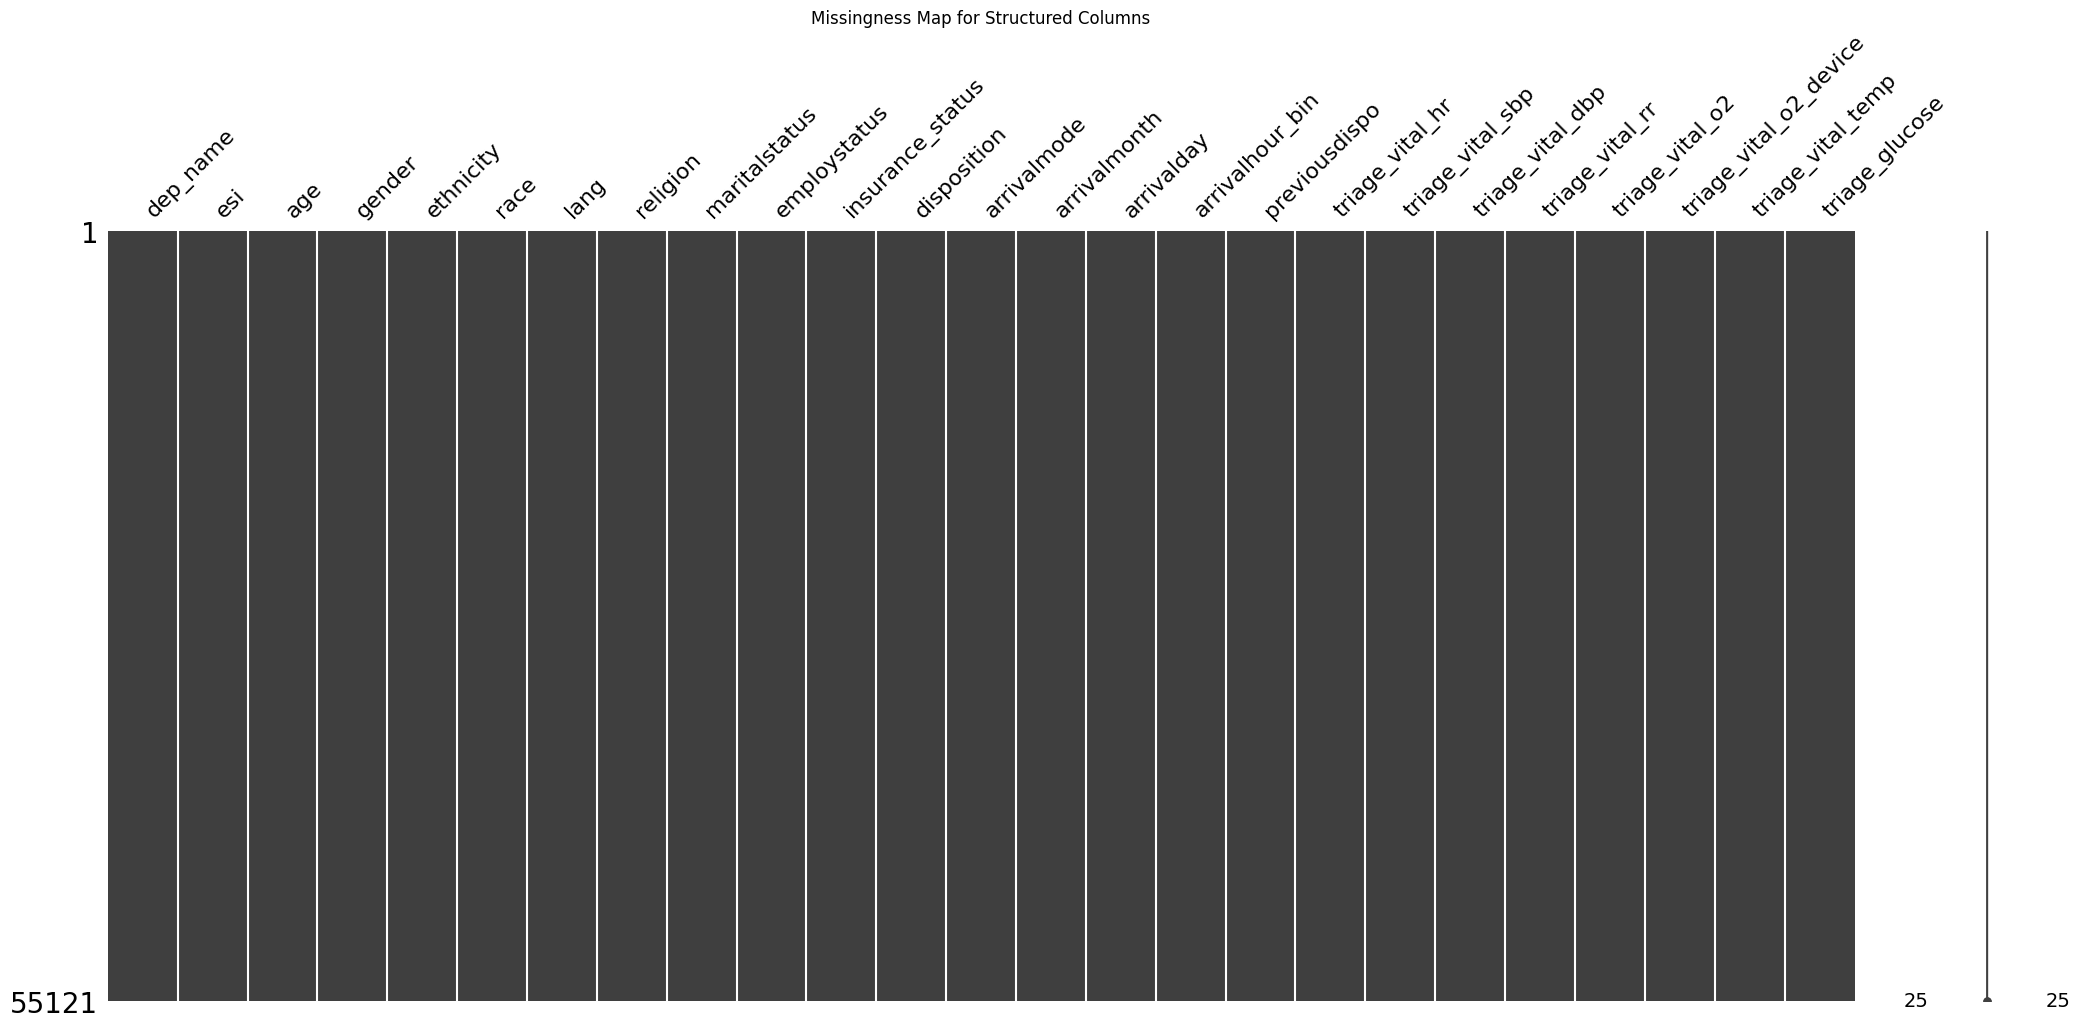

In [52]:
# Missingness map of the structured columns
# A full missingness map of all columns is difficult to read because the dataset has many chief complaint flags.

try:
    import missingno as msno

    msno.matrix(df[structured])
    plt.title("Missingness Map for Structured Columns", fontsize=12)
    plt.savefig(OUTPUT_DIR / "SOliver_Week5_Structured_Missingness_Map.png", dpi=300, bbox_inches="tight")
    plt.show()

except Exception:
    fig, ax = plt.subplots(figsize=(11, 4))

    ax.imshow(df[structured].isna().values, aspect="auto", cmap="gray_r")
    ax.set_xticks(range(len(structured)))
    ax.set_xticklabels(structured, rotation=90, fontsize=7)
    ax.set_xlabel("Structured features")
    ax.set_ylabel("Patient records")
    ax.set_title("Missingness Map for Structured Columns")

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "SOliver_Week5_Structured_Missingness_Map.png", dpi=300, bbox_inches="tight")
    plt.show()

### Interpretation: Structured Missingness Map

This plot focuses only on the structured columns because a missingness map across all chief complaint flags would be difficult to interpret visually. The structured variables are especially important for triage modelling because they include demographic fields, arrival information, ESI and vital signs.

The purpose of this visual is not to make a final modelling decision, but to quickly identify whether missing values are concentrated in specific clinical fields or spread across the dataset.

In [53]:
missingness = (
    df.isna()
    .sum()
    .reset_index()
    .rename(columns={"index": "feature", 0: "missing_count"})
)

missingness["missing_percent"] = (
    missingness["missing_count"] / len(df) * 100
).round(2)

missingness = missingness.sort_values("missing_percent", ascending=False)

missingness.head(25)

,feature,missing_count,missing_percent
0,dep_name,0,0.0
1,esi,0,0.0
2,age,0,0.0
3,gender,0,0.0
4,ethnicity,0,0.0
5,race,0,0.0
6,lang,0,0.0
7,religion,0,0.0
8,maritalstatus,0,0.0
9,employstatus,0,0.0


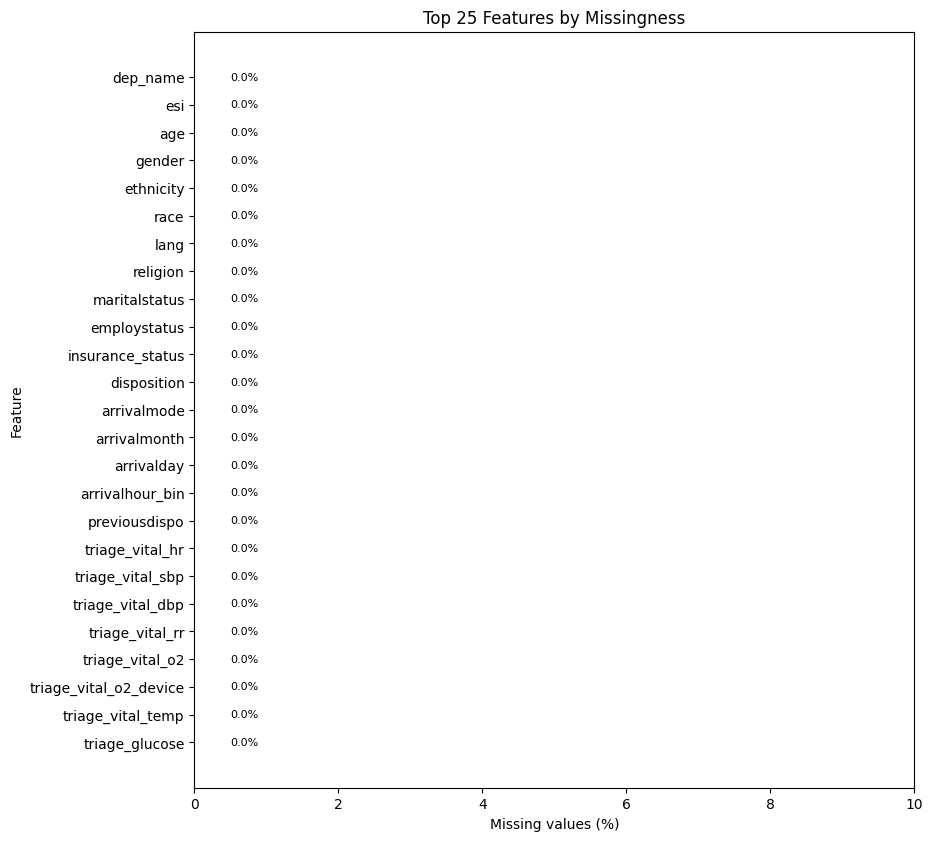

In [56]:
top_missing = missingness.head(25).copy()

fig, ax = plt.subplots(figsize=(12, 9))

ax.barh(top_missing["feature"], top_missing["missing_percent"])

ax.set_xlabel("Missing values (%)")
ax.set_ylabel("Feature")
ax.set_title("Top 25 Features by Missingness")
ax.invert_yaxis()

# Add percentage labels beside bars
for i, value in enumerate(top_missing["missing_percent"]):
    ax.text(
        value + 0.5,
        i,
        f"{value:.1f}%",
        va="center",
        fontsize=8
    )

# Give long feature names and percentage labels enough space
ax.set_xlim(0, max(top_missing["missing_percent"]) + 10)
plt.subplots_adjust(left=0.35, right=0.95, top=0.92, bottom=0.08)

plt.savefig(
    OUTPUT_DIR / "SOliver_Week5_Missingness_BarChart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 3. Data Types and Target Variable Review

Before modelling, it is important to confirm that the dataset variables are stored in appropriate formats. Numeric clinical variables such as age and vital signs should be usable as numbers, while demographic and administrative variables should be treated as categorical features.

This section also reviews the ESI triage level because it is the main target variable for Week 6 baseline modelling.

In [38]:
print(df[structured].dtypes)
print("\nESI value counts (raw):"); print(df[TARGET].value_counts(dropna=False).sort_index())

dep_name                   object
esi                       float64
age                       float64
gender                     object
ethnicity                  object
race                       object
lang                       object
religion                   object
maritalstatus              object
employstatus               object
insurance_status           object
disposition                object
arrivalmode                object
arrivalmonth               object
arrivalday                 object
arrivalhour_bin            object
previousdispo              object
triage_vital_hr           float64
triage_vital_sbp          float64
triage_vital_dbp          float64
triage_vital_rr           float64
triage_vital_o2           float64
triage_vital_o2_device    float64
triage_vital_temp         float64
triage_glucose            float64
dtype: object

ESI value counts (raw):
esi
1.0       77
2.0    17924
3.0    27010
4.0     8896
5.0     1214
Name: count, dtype: int64


In [57]:
dtype_summary = (
    df.dtypes
    .astype(str)
    .value_counts()
    .reset_index()
)

dtype_summary.columns = ["dtype", "number_of_columns"]

dtype_summary

,dtype,number_of_columns
0,float64,210
1,object,15


In [58]:
dtype_summary.to_csv(
    OUTPUT_DIR / "SOliver_Week5_Dtype_Summary.csv",
    index=False
)

In [59]:
column_profile = pd.DataFrame({
    "column_name": df.columns,
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isna().sum().values,
    "missing_percent": (df.isna().mean().values * 100).round(2),
    "unique_values": df.nunique(dropna=True).values
})

column_profile = column_profile.sort_values("missing_percent", ascending=False)

column_profile.head(25)

,column_name,dtype,missing_count,missing_percent,unique_values
dep_name,dep_name,object,0,0.0,3
esi,esi,float64,0,0.0,5
age,age,float64,0,0.0,88
gender,gender,object,0,0.0,2
ethnicity,ethnicity,object,0,0.0,4
race,race,object,0,0.0,8
lang,lang,object,0,0.0,2
religion,religion,object,0,0.0,12
maritalstatus,maritalstatus,object,0,0.0,10
employstatus,employstatus,object,0,0.0,10


In [60]:
column_profile.to_csv(
    OUTPUT_DIR / "SOliver_Week5_Column_Profile.csv",
    index=False
)

In [61]:
df["esi"].value_counts(dropna=False).sort_index()

,count
esi,
1.0,77
2.0,17924
3.0,27010
4.0,8896
5.0,1214


In [62]:
esi_summary = df["esi"].value_counts(dropna=False).sort_index().reset_index()
esi_summary.columns = ["esi_level", "record_count"]
esi_summary["percent"] = (esi_summary["record_count"] / len(df) * 100).round(1)

esi_summary

,esi_level,record_count,percent
0,1.0,77,0.1
1,2.0,17924,32.5
2,3.0,27010,49.0
3,4.0,8896,16.1
4,5.0,1214,2.2


In [63]:
esi_summary.to_csv(
    OUTPUT_DIR / "SOliver_Week5_ESI_Target_Summary.csv",
    index=False
)

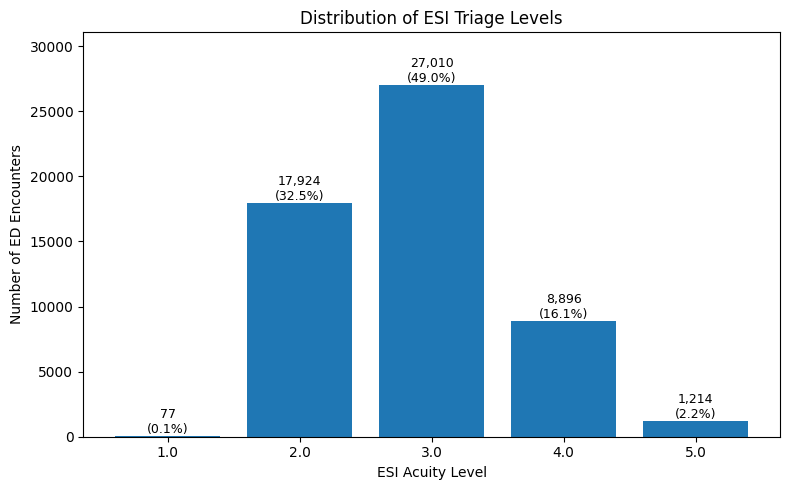

In [64]:
esi_counts = df["esi"].value_counts(dropna=False).sort_index()
esi_percent = (esi_counts / esi_counts.sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(esi_counts.index.astype(str), esi_counts.values)

ax.set_xlabel("ESI Acuity Level")
ax.set_ylabel("Number of ED Encounters")
ax.set_title("Distribution of ESI Triage Levels")

for bar, pct in zip(bars, esi_percent):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}\n({pct}%)",
        ha="center",
        va="bottom",
        fontsize=9
    )

ax.set_ylim(0, max(esi_counts.values) * 1.15)

plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "SOliver_Week5_ESI_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Interpretation: Data Types and ESI Target

The data type review confirms which variables are ready for numeric analysis and which variables need to be treated as categorical or indicator features. This is important because modelling errors can occur if clinical measurements are stored as text or if categorical variables are treated as continuous values.

The ESI variable is the target variable for the triage modelling task. Its distribution is important because a heavily imbalanced target can make a model appear accurate while still performing poorly for less common but clinically important acuity levels. For Week 6, model evaluation should therefore consider performance across ESI levels rather than relying only on overall accuracy.

At this stage, the ESI target appears usable for continued exploration, but the final feasibility memo should note any imbalance or missingness in the target before baseline modelling begins.

<div style="border-left:4px solid #6C5CE7;background:#f7f9fb;padding:10px 14px;border-radius:4px;font-family:Aptos,Calibri,sans-serif"><b style="color:#6C5CE7">🧩 PANDAS IN PLAIN ENGLISH</b><br><code>.dtypes</code> reports what <i>kind</i> of value each column holds — <code>float64</code> for numbers, <code>object</code> (or <code>str</code>) when text has sneaked into a numeric column. <code>.value_counts()</code> tallies how often each distinct value appears; <code>dropna=False</code> adds a row for the NaNs so missing labels can’t hide; <code>.sort_index()</code> orders the tally by ESI level (1→5).</div>

## 4. Clinical Feature Distributions

This section reviews the distribution of clinically important variables, especially triage vital signs and age. These features are important because they are commonly used by clinicians to assess acuity, deterioration risk and urgency at the point of triage.

The purpose of this section is to check whether the values appear clinically plausible and whether these features may be useful for baseline modelling in Week 6.

In [65]:
vital_summary = df[fam["vitals"]].describe().T

vital_summary["missing_count"] = df[fam["vitals"]].isna().sum()
vital_summary["missing_percent"] = (
    df[fam["vitals"]].isna().mean() * 100
).round(2)

vital_summary

,count,mean,std,min,25%,50%,75%,max,missing_count,missing_percent
triage_vital_hr,55121.0,86.447618,16.955556,32.0,74.0,85.0,97.0,221.0,0,0.0
triage_vital_sbp,55121.0,133.680403,22.645812,53.0,118.0,132.0,147.0,266.0,0,0.0
triage_vital_dbp,55121.0,79.531401,14.594082,27.0,70.0,79.0,89.0,189.0,0,0.0
triage_vital_rr,55121.0,17.842073,2.066015,8.0,16.0,18.0,18.0,66.0,0,0.0
triage_vital_o2,55121.0,97.021393,2.084465,62.0,96.0,98.0,98.0,99.0,0,0.0
triage_vital_temp,55121.0,98.090311,0.813266,91.5,97.7,98.0,98.4,106.0,0,0.0
triage_glucose,55121.0,130.086138,73.664073,16.0,93.0,107.0,134.0,1066.0,0,0.0


In [66]:
vital_summary.to_csv(
    OUTPUT_DIR / "SOliver_Week5_Vital_Sign_Summary.csv"
)

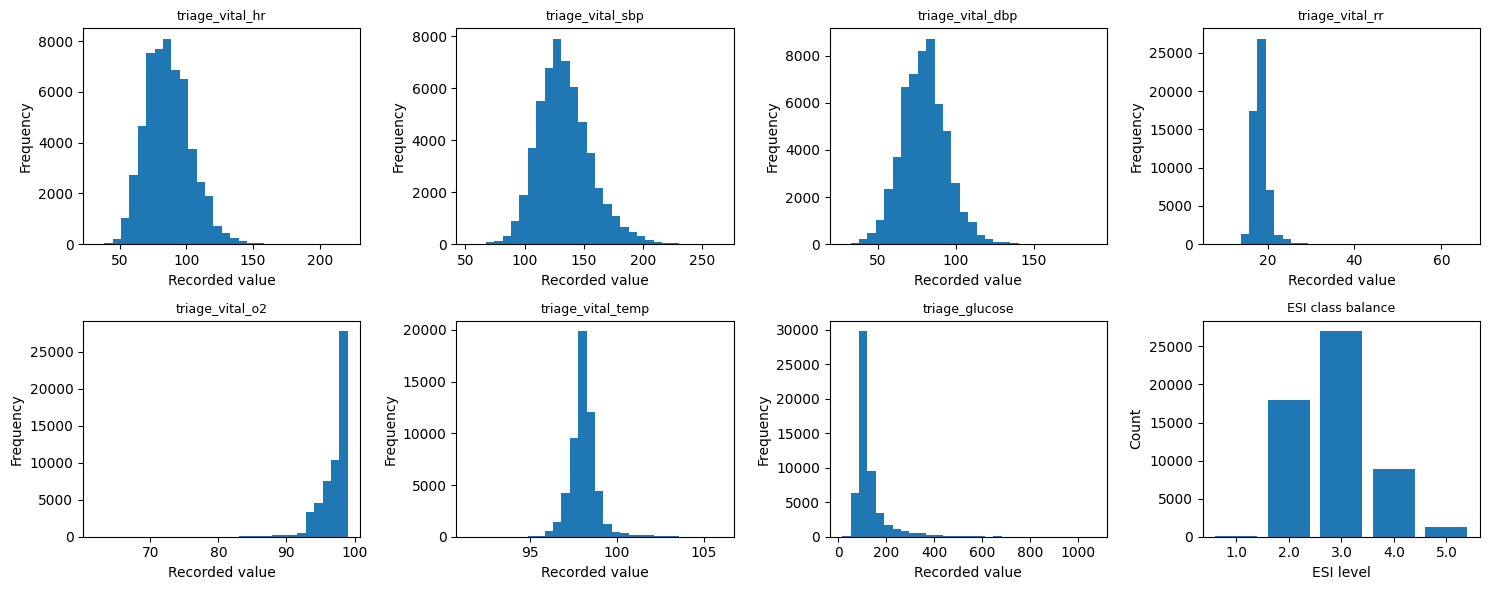

In [68]:
# Histograms for triage vital signs and ESI class balance

vitals = fam["vitals"]

fig, axes = plt.subplots(2, 4, figsize=(15, 6))
panels = axes.ravel()

# Plot each vital sign
for panel, col in zip(panels, vitals):
    values = pd.to_numeric(df[col], errors="coerce").dropna()
    panel.hist(values, bins=30)
    panel.set_title(col, fontsize=9)
    panel.set_xlabel("Recorded value")
    panel.set_ylabel("Frequency")

# Use the last panel for ESI class balance
esi_counts = df[TARGET].value_counts(dropna=False).sort_index()
panels[-1].bar(esi_counts.index.astype(str), esi_counts.values)
panels[-1].set_title("ESI class balance", fontsize=9)
panels[-1].set_xlabel("ESI level")
panels[-1].set_ylabel("Count")

# Hide unused panels if there are any
for panel in panels[len(vitals):-1]:
    panel.set_visible(False)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "SOliver_Week5_Vital_Signs_and_ESI_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<div style="border-left:4px solid #6C5CE7;background:#f7f9fb;padding:10px 14px;border-radius:4px;font-family:Aptos,Calibri,sans-serif"><b style="color:#6C5CE7">🧩 PANDAS IN PLAIN ENGLISH</b><br><code>pd.to_numeric(df[col], errors='coerce')</code> forces a column to numbers and quietly turns anything it can’t parse (like <code>'120bpm'</code>) into NaN instead of crashing — <code>coerce</code> = ‘don’t raise an error, just mark it missing’. <code>.dropna()</code> then drops those gaps so the histogram only plots real numbers. <code>zip(panels, vitals)</code> pairs panel 1 with vital 1, panel 2 with vital 2, and so on, so one loop fills the whole grid.</div>

### Interpretation: Vital Sign and ESI Distributions

The vital sign histograms provide an early view of whether the clinical measurements appear usable for modelling. These variables are important because they reflect the patient’s physiological state at triage and may help identify patients at higher risk of deterioration.

The ESI class balance plot shows the distribution of the target variable. This is important because if one ESI level is much more common than the others, a baseline model may appear accurate while still performing poorly on less common but clinically important acuity levels. For Week 6, model performance should therefore be assessed across ESI classes, not only by overall accuracy.

## 5. Outlier and Clinical Plausibility Checks

This section checks whether selected triage vital signs contain values that are statistically unusual or clinically implausible. In emergency department data, outliers should not be removed automatically because extreme values may represent true high-acuity patients. However, values outside plausible clinical ranges should be flagged because they may reflect documentation errors, unit errors or data entry problems.

In [73]:
def outlier_report(df, col):
    """Count two kinds of outlier in one numeric column."""
    x = pd.to_numeric(df[col], errors="coerce").dropna()

    # Statistical outliers using the 1.5 x IQR rule
    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)
    iqr = q3 - q1

    low_fence = q1 - 1.5 * iqr
    high_fence = q3 + 1.5 * iqr

    iqr_outliers = ((x < low_fence) | (x > high_fence)).sum()

    # Clinically impossible values using wide plausible bounds
    hard_low, hard_high = PLAUSIBLE.get(col, (-np.inf, np.inf))
    impossible = ((x < hard_low) | (x > hard_high)).sum()

    return {
        "count": x.count(),
        "min": x.min(),
        "median": x.median(),
        "max": x.max(),
        "iqr_outliers": iqr_outliers,
        "clinically_impossible": impossible,
        "plausible_low": hard_low,
        "plausible_high": hard_high
    }


report_rows = {}

for col in fam["vitals"]:
    report_rows[col] = outlier_report(df, col)

outlier_report_df = pd.DataFrame(report_rows).T

outlier_report_df

,count,min,median,max,iqr_outliers,clinically_impossible,plausible_low,plausible_high
triage_vital_hr,55121.0,32.0,85.0,221.0,578.0,0.0,20.0,250.0
triage_vital_sbp,55121.0,53.0,132.0,266.0,1028.0,0.0,50.0,300.0
triage_vital_dbp,55121.0,27.0,79.0,189.0,726.0,0.0,20.0,200.0
triage_vital_rr,55121.0,8.0,18.0,66.0,2366.0,4.0,4.0,60.0
triage_vital_o2,55121.0,62.0,98.0,99.0,1505.0,0.0,50.0,100.0
triage_vital_temp,55121.0,91.5,98.0,106.0,3554.0,0.0,86.0,110.0
triage_glucose,55121.0,16.0,107.0,1066.0,5673.0,25.0,20.0,800.0


In [74]:
outlier_report_df.to_csv(
    OUTPUT_DIR / "SOliver_Week5_Outlier_and_Plausibility_Report.csv"
)

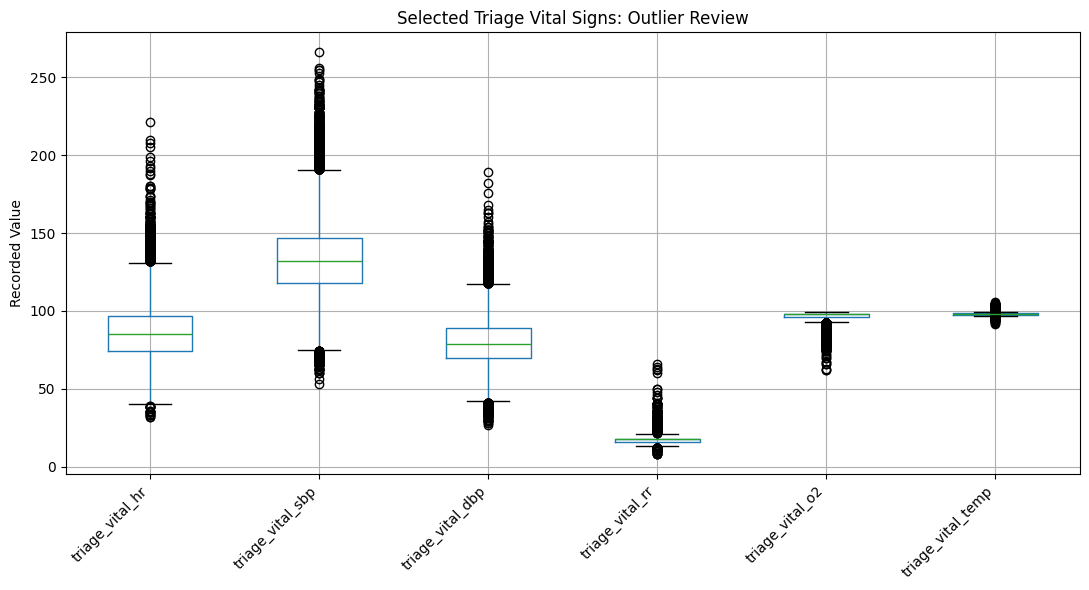

In [72]:
# Boxplot of selected vital signs for visual outlier review

selected_vitals = [
    col for col in [
        "triage_vital_hr",
        "triage_vital_sbp",
        "triage_vital_dbp",
        "triage_vital_rr",
        "triage_vital_o2",
        "triage_vital_temp"
    ]
    if col in df.columns
]

fig, ax = plt.subplots(figsize=(11, 6))

df[selected_vitals].apply(pd.to_numeric, errors="coerce").boxplot(ax=ax)

ax.set_title("Selected Triage Vital Signs: Outlier Review")
ax.set_ylabel("Recorded Value")
ax.set_xticklabels(selected_vitals, rotation=45, ha="right")

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "SOliver_Week5_Selected_Vital_Signs_Outlier_Boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation: Outlier and Plausibility Checks

The outlier report helps separate statistically unusual values from values that may be clinically impossible or unsafe to interpret. This distinction is important because a very abnormal vital sign may reflect genuine clinical deterioration rather than an error.

For the feasibility memo, clinically implausible values should be treated as data-quality concerns. They should not be corrected unless the source error is obvious. If they cannot be safely interpreted, they should be treated as missing or excluded from modelling. Statistical outliers, however, should be reviewed carefully because they may contain important information about high-acuity patients.

This means the dataset can still be used for baseline modelling, but the modelling pipeline should include clear rules for handling implausible values before training.

## 6. Demographic and Fairness-Sensitive Review

This section reviews demographic and fairness-sensitive variables in the dataset. These variables are important for data governance because they can help identify whether the dataset represents patient groups unevenly.

For this project, variables such as race, ethnicity and insurance status are reviewed mainly for data-quality and equity auditing. They should not be treated as automatic clinical predictors without a clear governance reason.

In [40]:
# Demographics — the fairness-sensitive view (raw categories)
for c in ["race","ethnicity","insurance_status"]:
    print(c, "->", df[c].value_counts(dropna=False).to_dict())

race -> {'White or Caucasian': 29435, 'Black or African American': 15963, 'Other': 9016, 'Patient Refused': 370, 'Asian': 175, 'Unknown': 76, 'American Indian or Alaska Native': 66, 'Native Hawaiian or Other Pacific Islander': 20}
ethnicity -> {'Non-Hispanic': 45142, 'Hispanic or Latino': 9888, 'Patient Refused': 56, 'Unknown': 35}
insurance_status -> {'Medicaid': 21427, 'Medicare': 17581, 'Commercial': 14056, 'Other': 1883, 'Self pay': 174}


In [75]:
demographic_summary = []

for c in ["race", "ethnicity", "insurance_status"]:
    if c in df.columns:
        counts = df[c].value_counts(dropna=False)
        percents = (counts / len(df) * 100).round(1)

        temp = pd.DataFrame({
            "variable": c,
            "category": counts.index.astype(str),
            "record_count": counts.values,
            "percent": percents.values
        })

        demographic_summary.append(temp)

demographic_summary_df = pd.concat(demographic_summary, ignore_index=True)

demographic_summary_df

,variable,category,record_count,percent
0,race,White or Caucasian,29435,53.4
1,race,Black or African American,15963,29.0
2,race,Other,9016,16.4
3,race,Patient Refused,370,0.7
4,race,Asian,175,0.3
5,race,Unknown,76,0.1
6,race,American Indian or Alaska Native,66,0.1
7,race,Native Hawaiian or Other Pacific Islander,20,0.0
8,ethnicity,Non-Hispanic,45142,81.9
9,ethnicity,Hispanic or Latino,9888,17.9


In [76]:
demographic_summary_df.to_csv(
    OUTPUT_DIR / "SOliver_Week5_Demographic_Summary.csv",
    index=False
)

### Interpretation: Demographic and Fairness-Sensitive Review

This demographic review is important because a future triage model may perform differently across patient groups if the dataset is unevenly represented or if some groups have less complete documentation. Race, ethnicity and insurance status can help identify possible equity concerns before modelling begins.

These variables should be handled carefully. For this project, I am treating them mainly as data-quality and fairness-auditing variables rather than automatic clinical predictors. They may be useful later for checking whether a model performs differently across groups, but they should not be used without clear governance justification.

At this stage, the demographic outputs do not prove that bias exists, but they show which categories need to be considered during feasibility review and Week 6 model evaluation. Any baseline model should be assessed beyond overall accuracy, including whether performance differs across patient groups.

In [79]:
# Define key column groups safely based on columns that actually exist in the dataset.
# This protects the notebook from errors if a column name is missing or slightly different.

vital_cols = [
    col for col in df.columns
    if any(term in col.lower() for term in ["vital", "hr", "sbp", "dbp", "rr", "o2", "temp", "glucose"])
]

chief_complaint_cols = [
    col for col in df.columns
    if col.lower().startswith("cc_")
]

demographic_cols = [
    col for col in ["age", "gender", "race", "ethnicity", "insurance_status"]
    if col in df.columns
]

print("Vital sign columns:", vital_cols)
print("Number of chief complaint columns:", len(chief_complaint_cols))
print("Demographic columns:", demographic_cols)

Vital sign columns: ['arrivalmode', 'arrivalmonth', 'arrivalday', 'arrivalhour_bin', 'triage_vital_hr', 'triage_vital_sbp', 'triage_vital_dbp', 'triage_vital_rr', 'triage_vital_o2', 'triage_vital_o2_device', 'triage_vital_temp', 'triage_glucose', 'cc_blurredvision', 'cc_cardiacarrest', 'cc_diarrhea', 'cc_headache-recurrentorknowndxmigraines', 'cc_irregularheartbeat', 'cc_skinirritation', 'cc_sorethroat']
Number of chief complaint columns: 200
Demographic columns: ['age', 'gender', 'race', 'ethnicity', 'insurance_status']


In [44]:
issues = [
    {
        "issue": "Missing ESI target labels",
        "columns": "esi",
        "action": "Rows without an ESI label should not be used for supervised triage modelling because the target outcome is unknown."
    },
    {
        "issue": "Missing values in triage vital signs",
        "columns": ", ".join(vital_cols),
        "action": "Measure missingness by vital sign. Do not blindly impute clinically important values; document gaps and consider missingness indicators or clinically justified imputation later."
    },
    {
        "issue": "Clinically impossible or implausible vital sign values",
        "columns": ", ".join(vital_cols),
        "action": "Flag values outside plausible clinical ranges for review. These should be corrected only if the source error is obvious; otherwise they should be treated as missing or excluded from modelling."
    },
    {
        "issue": "Temperature unit interpretation",
        "columns": "triage_vital_temp" if "triage_vital_temp" in df.columns else "temperature column not confirmed",
        "action": "Confirm the temperature unit before applying clinical rules, because confusing Fahrenheit and Celsius would create unsafe interpretation."
    },
    {
        "issue": "Sparse chief complaint indicators",
        "columns": "cc_*",
        "action": "Identify very low-prevalence chief complaint flags. Rare complaint indicators may have unstable correlations and should be grouped or handled carefully during modelling."
    },
    {
        "issue": "Potential class imbalance in ESI levels",
        "columns": "esi",
        "action": "Review the distribution of ESI levels. If some acuity levels are rare, model evaluation should not rely only on overall accuracy."
    },
    {
        "issue": "Fairness-sensitive demographic variables",
        "columns": ", ".join(demographic_cols),
        "action": "Use these variables for auditing equity and subgroup performance. Be careful about using them directly in modelling without a clear governance justification."
    },
    {
        "issue": "Single-site representativeness",
        "columns": "entire dataset",
        "action": "Treat findings as site-specific. External validation would be needed before using the model in other hospitals or regions."
    },
    {
        "issue": "Potential data leakage",
        "columns": "disposition and post-triage outcome variables, if present",
        "action": "Exclude variables that would not be known at the time of triage from baseline modelling, because they could make the model appear better than it truly is."
    }
]

issues_df = pd.DataFrame(issues)

issues_df

,issue,columns,action
0,Missing ESI target labels,esi,Rows without an ESI label should not be used f...
1,Missing values in triage vital signs,"arrivalmode, arrivalmonth, arrivalday, arrival...",Measure missingness by vital sign. Do not blin...
2,Clinically impossible or implausible vital sig...,"arrivalmode, arrivalmonth, arrivalday, arrival...",Flag values outside plausible clinical ranges ...
3,Temperature unit interpretation,triage_vital_temp,Confirm the temperature unit before applying c...
4,Sparse chief complaint indicators,cc_*,Identify very low-prevalence chief complaint f...
5,Potential class imbalance in ESI levels,esi,Review the distribution of ESI levels. If some...
6,Fairness-sensitive demographic variables,"age, gender, race, ethnicity, insurance_status",Use these variables for auditing equity and su...
7,Single-site representativeness,entire dataset,Treat findings as site-specific. External vali...
8,Potential data leakage,"disposition and post-triage outcome variables,...",Exclude variables that would not be known at t...


<div style="border-left:4px solid #6C5CE7;background:#f7f9fb;padding:10px 14px;border-radius:4px;font-family:Aptos,Calibri,sans-serif"><b style="color:#6C5CE7">🧩 PANDAS IN PLAIN ENGLISH</b><br><code>.copy()</code> makes a separate copy so editing it never touches the original <code>df</code>. <code>.corrwith(df[TARGET])</code> correlates <i>every</i> column against one target Series in a single step, returning one number per column between −1 and +1. A <b>negative</b> value means ‘as this vital goes up, <code>esi</code> goes down’ — and lower <code>esi</code> means more urgent.</div>

## 7. Feature Signal and Correlation With ESI

This section looks at simple correlations between selected clinical features and ESI. This is not a final modelling step, but it provides an early signal of which variables may be useful for Week 6 baseline modelling.

Because ESI is ordered, lower ESI values generally represent higher acuity. Therefore, negative correlations may indicate features associated with higher-acuity patients, while positive correlations may be associated with lower-acuity patients. These results should be interpreted carefully and combined with clinical judgement.

In [77]:
# Make a numeric copy of the vitals so we can correlate them with ESI.

vitals_numeric = df[fam["vitals"]].copy()

for col in fam["vitals"]:
    vitals_numeric[col] = pd.to_numeric(vitals_numeric[col], errors="coerce")

# Vitals vs ESI
vital_corr = vitals_numeric.corrwith(df[TARGET]).sort_values()

print("Vital signs vs ESI:")
print(vital_corr.round(3))

# Chief complaints vs ESI
cc_corr = (
    df[fam["chief_complaints"]]
    .corrwith(df[TARGET])
    .dropna()
    .sort_values()
)

print("\nChief complaints most associated with lower ESI / higher acuity:")
print(cc_corr.head(8).round(3))

Vital signs vs ESI:
triage_vital_rr     -0.095
triage_vital_hr     -0.095
triage_glucose      -0.078
triage_vital_temp   -0.022
triage_vital_sbp     0.001
triage_vital_dbp     0.046
triage_vital_o2      0.178
dtype: float64

Chief complaints most associated with lower ESI / higher acuity:
cc_chestpain               -0.164
cc_shortnessofbreath       -0.150
cc_suicidal                -0.143
cc_alcoholintoxication     -0.142
cc_alteredmentalstatus     -0.132
cc_psychiatricevaluation   -0.103
cc_weakness                -0.081
cc_syncope                 -0.075
dtype: float64


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [78]:
vital_corr.to_csv(
    OUTPUT_DIR / "SOliver_Week5_Vital_Correlation_With_ESI.csv"
)

cc_corr.to_csv(
    OUTPUT_DIR / "SOliver_Week5_Chief_Complaint_Correlation_With_ESI.csv"
)

In [45]:
issues_df.to_csv("SOliver_Week5_Data_Quality_Issues_Table.csv", index=False)

### Interpretation: Correlation With ESI

The correlation results provide an early signal of which clinical features may be useful for triage modelling. However, these values should not be treated as proof that a variable causes a particular ESI level. Emergency triage decisions are usually based on combinations of clinical findings rather than one feature alone.

Vital signs with stronger correlations may be useful candidates for Week 6 baseline modelling, especially if they are clinically meaningful and not heavily missing. Chief complaint flags may also provide useful context, particularly for symptoms associated with higher-acuity presentations.

These results will help refine the top-10 feature shortlist, but the final shortlist should combine both simple correlation and clinical reasoning.

## 8. Exercise Responses and Data-Quality Summary

This section completes the tutorial exercises by summarising the main data-quality findings from the profiling work above. These responses connect the code outputs to the Week 5 feasibility question: whether the dataset is suitable for baseline triage modelling.

### Exercise 1: Outlier Report

The outlier report was completed by comparing two types of unusual values. The first type is statistical outliers, identified using the 1.5 × IQR rule. The second type is clinically implausible values, identified using broad plausible clinical ranges for each vital sign.

This distinction matters because not every outlier is a data error. In emergency department data, extreme values may reflect true high-acuity patients. For example, very low oxygen saturation or very abnormal blood pressure may be clinically meaningful. However, clinically impossible values should be flagged for review because they may reflect unit errors, documentation errors or incorrect data entry.

In [80]:
# Exercise 2: Compare missing oxygen saturation with ESI

if "triage_vital_o2" in df.columns:
    missing_o2_summary = (
        df.assign(missing_o2=df["triage_vital_o2"].isna())
          .groupby("missing_o2")[TARGET]
          .agg(["count", "mean", "median"])
          .reset_index()
    )

    missing_o2_summary
else:
    print("triage_vital_o2 column not found.")

In [ ]:
if "triage_vital_o2" in df.columns:
    missing_o2_summary.to_csv(
        OUTPUT_DIR / "SOliver_Week5_Missing_O2_by_ESI.csv",
        index=False
    )

### Exercise 2: Missing Oxygen Saturation and ESI

Missing oxygen saturation should be reviewed carefully because missingness may not be random. If patients with missing oxygen saturation have a different ESI pattern from patients with recorded oxygen saturation, then the missingness may reflect clinical workflow, patient acuity or documentation timing.

This matters for modelling because missingness itself may carry information. It would not be safe to simply fill missing oxygen saturation values without understanding why they are missing.

In [81]:
# Exercise 3: Identify sparse chief complaint flags

cc_prevalence = df[fam["chief_complaints"]].mean().sort_values()

sparse_cc = cc_prevalence[cc_prevalence < 0.005]

print(f"Number of chief complaint flags with prevalence below 0.5%: {len(sparse_cc)}")
sparse_cc.head(20)

Number of chief complaint flags with prevalence below 0.5%: 149


,0
cc_cardiacarrest,0.000000
cc_fulltrauma,0.000073
cc_ingestion,0.000181
cc_bodyfluidexposure,0.000181
cc_exposuretostd,0.000236
cc_hyperglycemia,0.000254
cc_foreignbodyineye,0.000254
cc_trauma,0.000254
cc_modifiedtrauma,0.000290
cc_tickremoval,0.000308


In [47]:
sparse_cc.to_csv("SOliver_Week5_Sparse_Chief_Complaints.csv")

### Exercise 3: Sparse Chief Complaint Flags

Chief complaint indicators with very low prevalence may not provide stable modelling signal on their own. If only a very small number of patients have a particular complaint flag, any relationship with ESI may be unreliable.

For Week 6 modelling, rare chief complaint flags may need to be grouped into broader clinical categories or handled carefully so that the model does not overfit to very small patient groups.

In [82]:
# Exercise 4: Data-quality issues table

issues = [
    {
        "issue": "Missing ESI target labels",
        "columns": TARGET,
        "action": "Rows without an ESI label should not be used for supervised triage modelling because the target outcome is unknown."
    },
    {
        "issue": "Missing values in triage vital signs",
        "columns": ", ".join(vital_cols),
        "action": "Measure missingness by vital sign. Do not blindly impute clinically important values; document gaps and consider missingness indicators or clinically justified imputation later."
    },
    {
        "issue": "Clinically impossible or implausible vital sign values",
        "columns": ", ".join(vital_cols),
        "action": "Flag values outside plausible clinical ranges for review. Correct only if the source error is obvious; otherwise treat as missing or exclude from modelling."
    },
    {
        "issue": "Potential class imbalance in ESI levels",
        "columns": TARGET,
        "action": "Review ESI distribution. Model evaluation should not rely only on overall accuracy if some acuity levels are uncommon."
    },
    {
        "issue": "Sparse chief complaint indicators",
        "columns": "cc_*",
        "action": "Identify very rare complaint flags and consider grouping them into broader clinical categories before modelling."
    },
    {
        "issue": "Fairness-sensitive demographic variables",
        "columns": ", ".join(demographic_cols),
        "action": "Use these variables for equity auditing and subgroup performance review. Avoid using them directly in modelling without governance justification."
    },
    {
        "issue": "Potential data leakage",
        "columns": "disposition or post-triage outcome variables, if present",
        "action": "Exclude variables that would not be known at the time of triage from Week 6 baseline modelling."
    },
    {
        "issue": "Single-site representativeness",
        "columns": "entire dataset",
        "action": "Treat findings as site-specific. External validation would be needed before using the model in other hospitals."
    }
]

issues_df = pd.DataFrame(issues)

issues_df

,issue,columns,action
0,Missing ESI target labels,esi,Rows without an ESI label should not be used f...
1,Missing values in triage vital signs,"arrivalmode, arrivalmonth, arrivalday, arrival...",Measure missingness by vital sign. Do not blin...
2,Clinically impossible or implausible vital sig...,"arrivalmode, arrivalmonth, arrivalday, arrival...",Flag values outside plausible clinical ranges ...
3,Potential class imbalance in ESI levels,esi,Review ESI distribution. Model evaluation shou...
4,Sparse chief complaint indicators,cc_*,Identify very rare complaint flags and conside...
5,Fairness-sensitive demographic variables,"age, gender, race, ethnicity, insurance_status",Use these variables for equity auditing and su...
6,Potential data leakage,"disposition or post-triage outcome variables, ...",Exclude variables that would not be known at t...
7,Single-site representativeness,entire dataset,Treat findings as site-specific. External vali...


In [83]:
issues_df.to_csv(
    OUTPUT_DIR / "SOliver_Week5_Data_Quality_Issues_Table.csv",
    index=False
)

### Exercise 4: Data-Quality Issues Table

The data-quality issues table summarises the main concerns before baseline modelling. The dataset appears useful for continued exploration because it contains ESI labels, vital signs, demographic variables and detailed chief complaint indicators.

However, the dataset is not ready for clinical deployment. The main issues are missingness, possible class imbalance, sparse complaint flags, implausible values, potential data leakage and single-site limitations. These concerns do not prevent Week 6 baseline modelling, but they must be documented clearly in the feasibility memo.

## Interim Submission Summary

This notebook completed the initial data profiling for the Week 5 interim submission. The analysis reviewed missingness, data types, ESI target distribution, vital sign distributions, outliers, demographic variables, simple feature correlations and key data-quality issues.

At this stage, the dataset appears suitable for continued exploration and Week 6 baseline modelling, but only with important caveats. The main caveats are missing values in key clinical fields, possible imbalance in ESI levels, sparse chief complaint indicators, potential data leakage and limited generalisability beyond the original hospital setting.

For the final Week 5 submission, the next steps are to complete the feasibility memo, refine the top-10 feature shortlist, strengthen the data-quality dashboard and clearly document which variables should or should not be used for baseline modelling.